<a href="https://colab.research.google.com/github/kalpana222/CodeAlpha_Handwritten_Character_Recognition/blob/main/Handwritten_Character_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ✍️ Handwritten Character Recognition using CNN
CodeAlpha Machine Learning Internship

Name: Kalpana

Domain: Machine Learning

Project 3: Handwritten Character Recognition Model

## 🎯 Project Objective

The objective of this project is to develop a deep learning model capable of recognizing handwritten digits from images. The model uses Convolutional Neural Networks (CNNs) to automatically learn visual patterns and accurately classify handwritten characters.

###1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

###2. Load the MNIST Dataset

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)

print("Testing Images  :", X_test.shape)
print("Testing Labels  :", y_test.shape)

Training Images : (60000, 28, 28)
Training Labels : (60000,)
Testing Images  : (10000, 28, 28)
Testing Labels  : (10000,)


In [4]:
print("Unique Labels :", np.unique(y_train))

Unique Labels : [0 1 2 3 4 5 6 7 8 9]


###3. Data Understanding

#### Sample Images

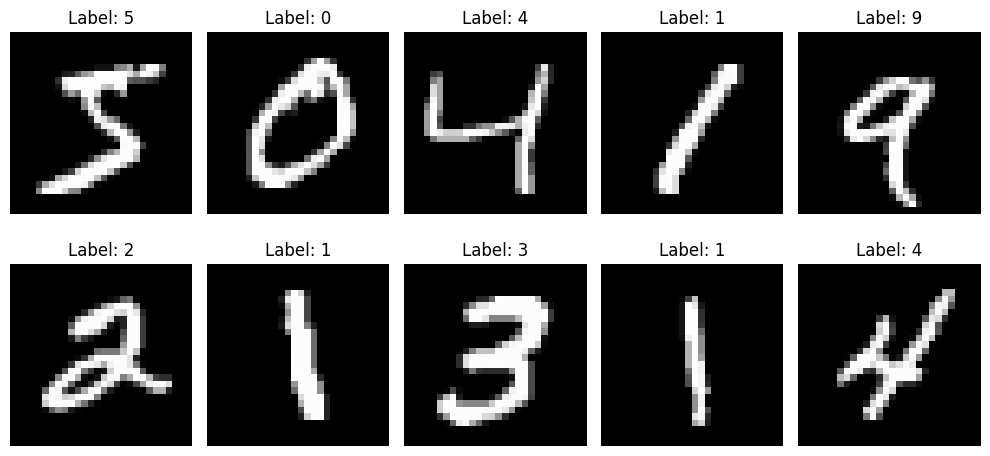

In [5]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

#### Image Dimensions


In [6]:
print("Shape of one image:", X_train[0].shape)

Shape of one image: (28, 28)


#### Pixel Value Range

In [7]:
print("Minimum Pixel Value :", X_train.min())
print("Maximum Pixel Value :", X_train.max())

Minimum Pixel Value : 0
Maximum Pixel Value : 255


###4. Data Preprocessing

#### Normalize Pixel Values


In [8]:
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Minimum Pixel Value :", X_train.min())
print("Maximum Pixel Value :", X_train.max())

Minimum Pixel Value : 0.0
Maximum Pixel Value : 1.0


#### Reshape Images

In [9]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (60000, 28, 28, 1)
Testing Shape  : (10000, 28, 28, 1)


####One-Hot Encode Labels

In [10]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

print("Training Labels Shape :", y_train.shape)
print("Testing Labels Shape  :", y_test.shape)

Training Labels Shape : (60000, 10)
Testing Labels Shape  : (10000, 10)


###5. Model Building

#### Build the CNN Model

In [11]:
# Create the CNN model
model = Sequential([

    # First Convolution Layer
    Input(shape=(28,28,1)),
    Conv2D(32, (3,3), activation="relu"),

    # Pooling Layer
    MaxPooling2D(pool_size=(2,2)),

    # Prevent Overfitting
    Dropout(0.25),

    # Convert 2D feature maps into 1D vector
    Flatten(),

    # Fully Connected Layer
    Dense(128, activation='relu'),

    # Prevent Overfitting
    Dropout(0.5),

    # Output Layer
    Dense(10, activation='softmax')
])

#### Model Summary

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

###6. Model Compilation & Training

###### Compile the Model

In [13]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


#### Train the Model

In [14]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.9139 - loss: 0.2851 - val_accuracy: 0.9737 - val_loss: 0.0883
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.9643 - loss: 0.1211 - val_accuracy: 0.9814 - val_loss: 0.0604
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.9713 - loss: 0.0940 - val_accuracy: 0.9843 - val_loss: 0.0534
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.9758 - loss: 0.0799 - val_accuracy: 0.9853 - val_loss: 0.0516
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - accuracy: 0.9788 - loss: 0.0695 - val_accuracy: 0.9867 - val_loss: 0.0441
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.9803 - loss: 0.0615 - val_accuracy: 0.9861 - val_loss: 0.0470
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.9833 - loss: 0.0516 - val_accuracy: 0.9871 - val_loss: 0.0441
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accuracy: 0.9843 -

#### Final Training Results

In [15]:
print("Final Training Accuracy    :", history.history["accuracy"][-1])
print("Final Validation Accuracy  :", history.history["val_accuracy"][-1])

Final Training Accuracy    : 0.9868749976158142
Final Validation Accuracy  : 0.9878333210945129


### 7. Model Evaluation

#### Evaluate the CNN Model

In [16]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss     :", round(test_loss, 4))
print("Test Accuracy :", round(test_accuracy * 100, 2), "%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9878 - loss: 0.0401
Test Loss     : 0.0401
Test Accuracy : 98.78 %


#### Generate Predictions

In [17]:
predictions = model.predict(X_test)
print("Prediction Shape :", predictions.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Prediction Shape : (10000, 10)


In [18]:
y_pred = np.argmax(predictions, axis=1)
y_true = np.argmax(y_test, axis=1)

print("Predicted Labels:")
print(y_pred[:10])

print()

print("Actual Labels:")
print(y_true[:10])

Predicted Labels:
[7 2 1 0 4 1 4 9 5 9]

Actual Labels:
[7 2 1 0 4 1 4 9 5 9]


#### Classification Report

In [19]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.98      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.98      0.99      0.98      1028
           8       0.99      0.98      0.99       974
           9       0.99      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



#### Confusion Matrix

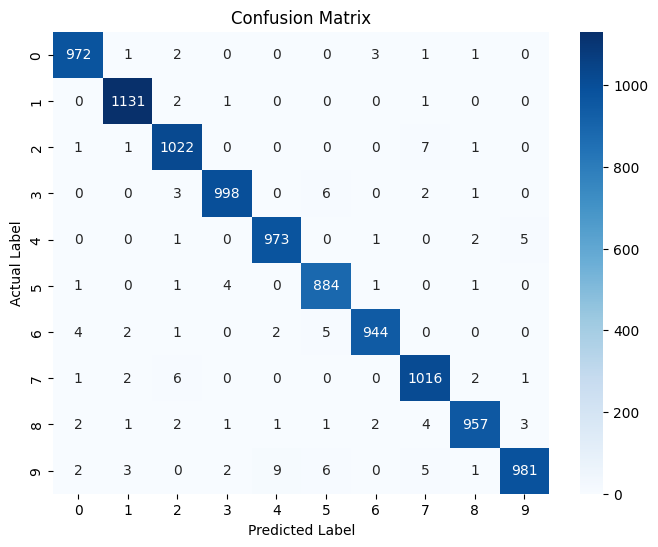

In [20]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

###8. Handwritten Digit Prediction

#### Predict Sample Handwritten Digits

In [26]:
predictions = model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)

actual_labels = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


#### Visualize Predictions

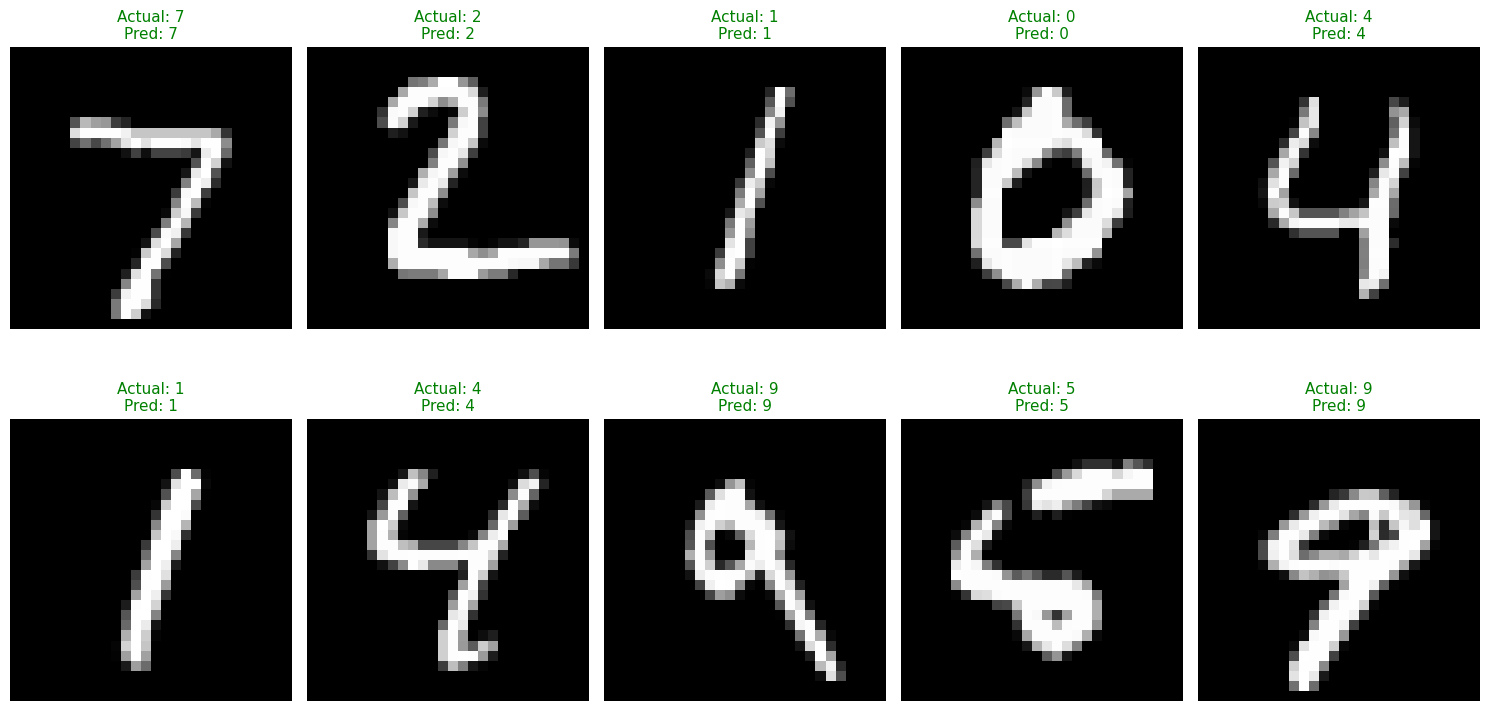

In [27]:
plt.figure(figsize=(15,8))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_test[i].reshape(28,28), cmap="gray")

    if predicted_labels[i] == actual_labels[i]:
        color = "green"
    else:
        color = "red"

    plt.title(
        f"Actual: {actual_labels[i]}\nPred: {predicted_labels[i]}",
        color=color,
        fontsize=11
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

#### Predict a Random Handwritten Digit

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


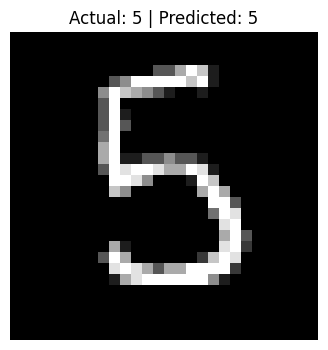

✅ Correct Prediction!


In [28]:
import random

index = random.randint(0, len(X_test)-1)

image = X_test[index]
prediction = model.predict(image.reshape(1,28,28,1))

predicted_digit = np.argmax(prediction)
actual_digit = actual_labels[index]

plt.figure(figsize=(4,4))
plt.imshow(image.reshape(28,28), cmap="gray")
plt.title(f"Actual: {actual_digit} | Predicted: {predicted_digit}")
plt.axis("off")
plt.show()

if predicted_digit == actual_digit:
    print("✅ Correct Prediction!")
else:
    print("❌ Incorrect Prediction!")

##Conclusion

This project successfully developed a Handwritten Character Recognition System using a Convolutional Neural Network (CNN) and the MNIST handwritten digits dataset. The dataset was explored and preprocessed by normalizing pixel values, reshaping images, and encoding class labels to prepare the data for deep learning.

A CNN model was designed, trained, and evaluated to classify handwritten digits accurately. The model achieved approximately 98.83% test accuracy, demonstrating its ability to recognize handwritten digits with high precision. Performance was further assessed using a Classification Report, Confusion Matrix, and sample predictions, confirming that the model generalized well on unseen data.

This project highlights the effectiveness of deep learning techniques in image classification tasks and provides a strong foundation for developing more advanced handwritten text recognition systems, such as alphabet, word, or sentence recognition using architectures like EMNIST and CRNN.

Overall, the project demonstrates the practical application of computer vision, image preprocessing, and Convolutional Neural Networks for solving real-world handwritten character recognition problems.